# Download and unzip data
Uncomment the code if you have not downloaded the data.

In [1]:
# from huggingface_hub import snapshot_download
# import zipfile
# from pathlib import Path

# # Download the data from openretina
# snapshot_download(
#     repo_id="open-retina/open-retina",
#     repo_type="dataset",
#     allow_patterns="franke_lab/qiu_2026/*",
#     local_dir="./data"
# )

# # Unzip data
# zip_dir = Path("./data/franke_lab/qiu_2026")
# for zip_file in zip_dir.glob("*.zip"):
#     with zipfile.ZipFile(zip_file, "r") as z:
#         z.extractall(zip_dir)
#     print(f"Extracted {zip_file}")

# Install dependencies
Uncomment the code if you have not installed dependencies.

In [ ]:
# !bash install_dependencies.sh # download sensorium_2023, neuralpredictors, nnfabrik, mei

# Prepare

In [2]:
seed = 111
random_seed = 111

In [3]:
# for auto-reloading external modules
%load_ext autoreload
%autoreload 2

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import cm
from matplotlib.colors import ListedColormap
import seaborn as sns
import re
import pandas as pd
import torch
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.inspection import permutation_importance
from scipy.stats import linregress, pearsonr
from collections import Counter
import pickle
# import shap

from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.datasets import make_classification
from sklearn.metrics import classification_report, confusion_matrix, balanced_accuracy_score
from sklearn.base import BaseEstimator, TransformerMixin, RegressorMixin
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_poisson_deviance, make_scorer
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score

import sys
sys.path.append('./src/sensorium_2023')
sys.path.append('./src/neuralpredictors')
sys.path.append('./src/nnfabrik')
from nnfabrik.utility.nn_helpers import set_random_seed
set_random_seed(seed)
from sensorium.datasets.mouse_video_loaders import mouse_video_loader
from sensorium.utility.scores import get_correlations, get_signal_correlations, model_predictions_align, get_responses_align
from nnfabrik.builder import get_trainer
from sensorium.models.make_model import make_video_model

In [5]:
# for plot figures
plt.rcParams.update({'figure.max_open_warning': 0})
#Output matplotlib figure to SVG with text as text, not curves
plt.rcParams['svg.fonttype'] = 'none'
# axis spine
#use it like: adjust_spines(ax, ['left', 'bottom'])
def adjust_spines(ax, spines):
    for loc, spine in ax.spines.items():
        if loc in spines:
            spine.set_position(('outward', 2))  # outward by 2 points
            #spine.set_smart_bounds(True)
        else:
            spine.set_color('none')  # don't draw spine
    # turn off ticks where there is no spine
    if 'left' in spines:
        ax.yaxis.set_ticks_position('left')
    else:
        # no yaxis ticks
        ax.yaxis.set_ticks([])
    if 'bottom' in spines:
        ax.xaxis.set_ticks_position('bottom')
    else:
        # no xaxis ticks
        ax.xaxis.set_ticks([])

# Load Data

In [6]:
paths = [
    './data/franke_lab/qiu_2026/' + '/dynamic29163-4-4-Fluorescence-7b721b-v4a/',
    './data/franke_lab/qiu_2026/' + '/dynamic28188-18-4-Fluorescence-7b721b-v4a/',
    './data/franke_lab/qiu_2026/' + '/dynamic28712-3-8-Fluorescence-7b721b-v4a/',
    './data/franke_lab/qiu_2026/' + '/dynamic29163-6-5-Fluorescence-7b721b-v4a/',
    './data/franke_lab/qiu_2026/' + '/dynamic29163-5-8-Fluorescence-7b721b-v4a/',
    './data/franke_lab/qiu_2026/' + '/dynamic28188-19-9-Fluorescence-7b721b-v4a/',
    # four scans with limited training data (fewer than ```120``` trials)
    './data/franke_lab/qiu_2026/' + '/dynamic28188-17-2-Fluorescence-7b721b-v4a/',
    './data/franke_lab/qiu_2026/' + '/dynamic29163-2-7-Fluorescence-7b721b-v4a/',
    './data/franke_lab/qiu_2026/' + '/dynamic28188-16-5-Fluorescence-7b721b-v4a/',
    './data/franke_lab/qiu_2026/' + '/dynamic28188-16-3-Fluorescence-7b721b-v4a/',
] 
neuron_ids_paths = [
    './data/franke_lab/qiu_2026/data-quality'+'/dynamic29163-4-4-Fluorescence-7b7_neurons_fluor_good.npy',
    './data/franke_lab/qiu_2026/data-quality'+'/dynamic28188-18-4-Fluorescence-7b7_neurons_fluor_good.npy',
    './data/franke_lab/qiu_2026/data-quality'+'/dynamic28712-3-8-Fluorescence-7b7_neurons_fluor_good.npy',
    './data/franke_lab/qiu_2026/data-quality'+'/dynamic29163-6-5-Fluorescence-7b7_neurons_fluor_good.npy',
    './data/franke_lab/qiu_2026/data-quality'+'/dynamic29163-5-8-Fluorescence-7b7_neurons_fluor_good.npy',
    './data/franke_lab/qiu_2026/data-quality'+'/dynamic28188-19-9-Fluorescence-7b7_neurons_fluor_good.npy',
    # four scans with limited training data (fewer than ```120``` trials)
    './data/franke_lab/qiu_2026/data-quality'+'/dynamic28188-17-2-Fluorescence-7b7_neurons_fluor_good.npy',
    './data/franke_lab/qiu_2026/data-quality'+'/dynamic29163-2-7-Fluorescence-7b7_neurons_fluor_good.npy',
    './data/franke_lab/qiu_2026/data-quality'+'/dynamic28188-16-5-Fluorescence-7b7_neurons_fluor_good.npy',
    './data/franke_lab/qiu_2026/data-quality'+'/dynamic28188-16-3-Fluorescence-7b7_neurons_fluor_good.npy',
]

print("Loading data..")
data_loader_config = {'batch_size': 3} # 7
data_loaders = mouse_video_loader(
    paths=paths,
    neuron_ids=[np.load(temp) for temp in neuron_ids_paths],
    batch_size=data_loader_config['batch_size'], # 8
    # scale=1,
    # max_frame=None,
    # frames=data_loader_config['frames'], # 100
    subtract_response_min=True,
    # offset=-1,
    include_behavior=True,
    include_pupil_centers=True,
    cuda=True, # True
    # to_cut=data_loader_config['to_cut'],
    behavior_channels=[0,2],
    random_sample_within_snippet_flag=False, # True
    num_random_subsequence=3, # 40
    subsequence_length=100,
    sequence_length=300, # 300
    random_start=np.array([0, 100, 200]), # 200
) #behaviror: (puil size, pupil size change, locomotion) 

Loading data..


In [7]:
data_loaders

{np.str_('train'): {'dynamic29163-4-4-Fluorescence-7b721b-v4a': <torch.utils.data.dataloader.DataLoader at 0x7fc899d52770>,
  'dynamic28188-18-4-Fluorescence-7b721b-v4a': <torch.utils.data.dataloader.DataLoader at 0x7fc899d52fe0>,
  'dynamic28712-3-8-Fluorescence-7b721b-v4a': <torch.utils.data.dataloader.DataLoader at 0x7fc899d53730>,
  'dynamic29163-6-5-Fluorescence-7b721b-v4a': <torch.utils.data.dataloader.DataLoader at 0x7fc899d52350>,
  'dynamic29163-5-8-Fluorescence-7b721b-v4a': <torch.utils.data.dataloader.DataLoader at 0x7fc899d0bca0>,
  'dynamic28188-19-9-Fluorescence-7b721b-v4a': <torch.utils.data.dataloader.DataLoader at 0x7fc899d37e50>,
  'dynamic28188-17-2-Fluorescence-7b721b-v4a': <torch.utils.data.dataloader.DataLoader at 0x7fc899d37160>,
  'dynamic29163-2-7-Fluorescence-7b721b-v4a': <torch.utils.data.dataloader.DataLoader at 0x7fc899d37b50>,
  'dynamic28188-16-5-Fluorescence-7b721b-v4a': <torch.utils.data.dataloader.DataLoader at 0x7fc899d370a0>,
  'dynamic28188-16-3-Flu

In [8]:
print ('Show a batch of data:')
tier = 'train'
dataset_name = list(data_loaders['train'].keys())[0] # 'dynamic28188-18-4-Activity-a0e5a8'
# for batch in data_loaders[tier][dataset_name]:
#     pass
# #
# # each batch is a NameTuple, containing the images, neuronal responses, and the behavioral variables
# print(batch._fields)
# #
# # Inspecting the content of a batch
# for i, field in enumerate(batch._fields):
#     print(f"{field}, {batch[i].shape}")
# # what will get printed:
# # images: N images, channels, height, width
# # responses: N images, N neurons
# # behavior: N images, N=3 behaviors (pupil size, instantaneous change of pupil size, locomotion speed)
# # pupil_center: N images, N=2 eye position traces: horizontal and vertical eye position

Show a batch of data:


In [9]:
for ii,batch in enumerate(data_loaders[tier][dataset_name]):
    if ii<2:
        print (batch[0].shape)
    else:
        break

torch.Size([3, 3, 299, 36, 64])
torch.Size([3, 3, 299, 36, 64])


In [10]:
# 'oracle'
for ii,batch in enumerate(data_loaders['validation'][dataset_name]):
    if ii<2:
        print (batch[0].shape)
    else:
        break

torch.Size([1, 3, 299, 36, 64])
torch.Size([1, 3, 299, 36, 64])


In [11]:
# # 'live_test_main'
# for ii,batch in enumerate(data_loaders['test'][dataset_name]):
#     if ii<2:
#         print (batch[0].shape)
#     else:
#         break

In [12]:
# 'oracle'
for ii,batch in enumerate(data_loaders['validation'][dataset_name]):
    if ii<2:
        print (batch[1].shape)
    else:
        break

torch.Size([1, 3175, 299])
torch.Size([1, 3175, 299])


# Factorised 3D core and Gaussian readout

In [13]:
factorised_3D_core_dict = dict(
    input_channels=3, # 3
    hidden_channels=[64, 64, 64], # [32, 64, 128]
    spatial_input_kernel=(11,11),
    temporal_input_kernel=11,
    spatial_hidden_kernel=(5,5),
    temporal_hidden_kernel=5,
    stride=1,
    layers=3,
    gamma_input_spatial=10,
    gamma_input_temporal=0.01, 
    bias=True, 
    hidden_nonlinearities='elu', 
    x_shift=0, 
    y_shift=0,
    batch_norm=True, 
    laplace_padding=None,
    input_regularizer='LaplaceL2norm',
#     padding=True,
    padding=False,
    final_nonlin=True,
    independent_bn_bias=True,
#     pad_time=False,
    momentum=0.7
)

shifter_dict = dict(
    gamma_shifter=0,
    shift_layers=3,
    input_channels_shifter=2,
    hidden_channels_shifter=5,
)

readout_dict = dict(
    bias=True,
    init_mu_range=0.1,
    init_sigma=0.3,
    gamma_readout=1.0,
    gauss_type='full',
    grid_mean_predictor={
        'type': 'cortex',
        'input_dimensions': 2,
        'hidden_layers': 1,
        'hidden_features': 30,
        'final_tanh': True
    },
    # grid_mean_predictor=None,
    share_features=False,
    share_grid=False,
    shared_match_ids=None,
    gamma_grid_dispersion=0.0,
)

In [14]:
factorised_3d_model = make_video_model(
    data_loaders,
    seed,
    core_dict=factorised_3D_core_dict,
    core_type='3D_factorised',
    readout_dict=readout_dict.copy(),
    readout_type='gaussian',               
    use_gru=False,
    gru_dict=None,
    use_shifter=True,
    shifter_dict=shifter_dict,
    shifter_type='MLP',
    feature_latent_flag=True, # True # False
    feature_latent_dim=2,
    position_encoding_flag=False,
    position_encoding_k=16,
)

/mnt/scratch09/yongrong/projects/retina-axon-model/Analyses/Digital_twin_model/./src/neuralpredictors/neuralpredictors/layers/readouts/base.py:74: UserWarning: Use of 'gamma_readout' is deprecated. Use 'feature_reg_weight' instead. If 'feature_reg_weight' is defined, 'gamma_readout' is ignored
  warnings.warn(


In [15]:
factorised_3d_model

VideoFiringRateEncoder(
  (core): Factorized3dCore(
    (_input_weight_regularizer): LaplaceL2norm(
      (laplace): Laplace()
    )
    (temporal_regularizer): DepthLaplaceL21d(
      (laplace): Laplace1d()
    )
    (features): Sequential(
      (layer0): Sequential(
        (conv_spatial): Conv3d(3, 64, kernel_size=(1, 11, 11), stride=(1, 1, 1))
        (conv_temporal): Conv3d(64, 64, kernel_size=(11, 1, 1), stride=(1, 1, 1))
        (norm): BatchNorm3d(64, eps=1e-05, momentum=0.7, affine=True, track_running_stats=True)
        (nonlin): ELU(alpha=1.0)
      )
      (layer1): Sequential(
        (conv_spatial_1): Conv3d(64, 64, kernel_size=(1, 5, 5), stride=(1, 1, 1))
        (conv_temporal_1): Conv3d(64, 64, kernel_size=(5, 1, 1), stride=(1, 1, 1))
        (norm): BatchNorm3d(64, eps=1e-05, momentum=0.7, affine=True, track_running_stats=True)
        (nonlin): ELU(alpha=1.0)
      )
      (layer2): Sequential(
        (conv_spatial_2): Conv3d(64, 64, kernel_size=(1, 5, 5), stride=(

In [16]:
# print (factorised_3d_model.readout['dynamic29163-4-4-Fluorescence-7b721b'].feature_latent.shape)
# print (factorised_3d_model.readout['dynamic29163-4-4-Fluorescence-7b721b'].feature_mlp)
# print (factorised_3d_model.readout['dynamic29163-4-4-Fluorescence-7b721b'].features.shape)

# Evaluation 

In [17]:
# from torch.func import jacfwd, vmap
# modelfile = './out/' + 'data_retina_sc_multiple_v4a_fluor_model_fac3d_seed_111_' + 'v05aaa' + '.pth' 
device = torch.device("cuda:0") # torch.device("cuda:0") # "cuda:0", torch.device("cpu")
cuda_flag = False if device == torch.device("cpu") else True
print (f'cuda_flag: {cuda_flag}')
datakeys = list(data_loaders['train'].keys())
print (datakeys)
# datakey = list(data_loaders['train'].keys())[0]

cuda_flag: True
['dynamic29163-4-4-Fluorescence-7b721b-v4a', 'dynamic28188-18-4-Fluorescence-7b721b-v4a', 'dynamic28712-3-8-Fluorescence-7b721b-v4a', 'dynamic29163-6-5-Fluorescence-7b721b-v4a', 'dynamic29163-5-8-Fluorescence-7b721b-v4a', 'dynamic28188-19-9-Fluorescence-7b721b-v4a', 'dynamic28188-17-2-Fluorescence-7b721b-v4a', 'dynamic29163-2-7-Fluorescence-7b721b-v4a', 'dynamic28188-16-5-Fluorescence-7b721b-v4a', 'dynamic28188-16-3-Fluorescence-7b721b-v4a']


## CC - explicit readout

In [ ]:
feature_latent_flags = [False]
unit_speed_flag = False
position_encoding_flag = False
wandb_suffixes = ['v05aaa'] # v05aa: explicit readout + no cortex coordinates; v05aaa: explicit readout + cortex coordinates
for ii in range(len(feature_latent_flags)):
    tempmodelfile = '../../models/' + 'data_retina_sc_multiple_v4a_fluor_model_fac3d_seed_111_' + wandb_suffixes[ii] + '.pth' 
    factorised_3d_model = make_video_model(
        data_loaders,
        seed,
        core_dict=factorised_3D_core_dict,
        core_type='3D_factorised',
        readout_dict=readout_dict.copy(),
        readout_type='gaussian',               
        use_gru=False,
        gru_dict=None,
        use_shifter=True,
        shifter_dict=shifter_dict,
        shifter_type='MLP',
        feature_latent_flag=feature_latent_flags[ii], # True # False
        feature_latent_dim=2,
        position_encoding_flag=position_encoding_flag,
        position_encoding_k=16,
    )
    factorised_3d_model.load_state_dict(torch.load(tempmodelfile, weights_only=True))
    factorised_3d_model.eval()
    val_correlation = get_correlations(
            factorised_3d_model, data_loaders["validation"], device=device, as_dict=False, per_neuron=False
        )
    print(f'Feature_latent_flags {feature_latent_flags[ii]}, val_correlation: {val_correlation:.4f}')
    # evaluation_hashes_unique, single_trial_corrs, mean_corrs = get_signal_correlations(
    #     factorised_3d_model, data_loaders, tier='test', stimulus_type='clip', evaluation_hashes_unique=['5zQTb77qI+ig8rigx1XU', \
    #     '7UETOWO5Z8aWuHDBJ2GG', 'GjCMo2GkJp6y5vricadg', 'KXdTNAGMo1gCWz2Ge8zr', 'Oup5uAZxF2G7zEJkT+ui', 'ecUQJtcERZJGdqza1k7h'],
    #     device=device, as_dict=True, per_neuron=True,
    # )
    # # print (f'single-trial-corr: {np.mean(single_trial_corrs[datakey]):.4f}')
    # # print (f'mean-corr: {np.mean(mean_corrs[datakey]):.4f}')
    # print (f'evaluation_hashes_unique: {evaluation_hashes_unique}')

# Compute responses to custom stimuli

In [19]:
# the pixel values should lie within (0.0, 255.0)
num_frames = 500
np.random.seed(10)
custom_stimuli = np.random.uniform(low=0.0, high=255.0 , size=(num_frames, 36, 64))

data_key = list(data_loaders['train'].keys())[0]
print (f'data_key: {data_key}')
dat = data_loaders["train"][data_key].dataset
custom_stimuli = (custom_stimuli - dat.statistics.videos.all.mean.flatten()[0])/dat.statistics.videos.all.std.flatten()[0]
print (f'After normalizing, np.max(custom_stimuli): {np.max(custom_stimuli)}')

beh = (dat.statistics.behavior.all.mean[:,0]/dat.statistics.behavior.all.std[:,0])[[0,2]]
print (f'behavior: {beh}')
beh = np.tile(beh, custom_stimuli.shape + (1,1,))
print (f'beh.shape: {beh.shape}')
beh = np.transpose(beh, (3,4,0,1,2))
print (f'beh.shape: {beh.shape}')
print ('\n')

custom_stimuli = np.tile(custom_stimuli, (1,1,1,1,1))
print (f'custom_stimuli.shape: {custom_stimuli.shape}')
# add pupil_size and locomotion to custom_stimuli
custom_stimuli = np.concatenate((custom_stimuli, beh), axis=1)
print (f'custom_stimuli.shape: {custom_stimuli.shape}')

data_key: dynamic29163-4-4-Fluorescence-7b721b-v4a
After normalizing, np.max(custom_stimuli): 2.8634881117032114
behavior: [6.151921   0.19004148]
beh.shape: (500, 36, 64, 1, 2)
beh.shape: (1, 2, 500, 36, 64)


custom_stimuli.shape: (1, 1, 500, 36, 64)
custom_stimuli.shape: (1, 3, 500, 36, 64)


In [20]:
custom_stimuli[0, 0, :20, 0, 0]

array([ 1.91667903,  0.98748898,  2.67849494,  2.48864008,  2.04339956,
       -0.38246497, -0.12340024,  2.04358876,  1.27229846,  1.46692939,
        1.57297207,  1.52493759,  0.67844729, -0.98970185,  2.64187268,
        0.68741408,  2.66300751,  1.30788569,  1.62579842,  0.29876847])

In [21]:
feature_latent_flags = [False]
unit_speed_flag = False
position_encoding_flag = False
wandb_suffixes = ['v05aaa']
ii=0
tempmodelfile = '../../models/' + 'data_retina_sc_multiple_v4a_fluor_model_fac3d_seed_111_' + wandb_suffixes[ii] + '.pth' 
factorised_3d_model = make_video_model(
    data_loaders,
    seed,
    core_dict=factorised_3D_core_dict,
    core_type='3D_factorised',
    readout_dict=readout_dict.copy(),
    readout_type='gaussian',               
    use_gru=False,
    gru_dict=None,
    use_shifter=True,
    shifter_dict=shifter_dict,
    shifter_type='MLP',
    feature_latent_flag=feature_latent_flags[ii], # True # False
    feature_latent_dim=2,
    position_encoding_flag=position_encoding_flag,
    position_encoding_k=16,
)
factorised_3d_model.load_state_dict(torch.load(tempmodelfile, weights_only=True))
factorised_3d_model = factorised_3d_model.to(device)
factorised_3d_model.eval()

VideoFiringRateEncoder(
  (core): Factorized3dCore(
    (_input_weight_regularizer): LaplaceL2norm(
      (laplace): Laplace()
    )
    (temporal_regularizer): DepthLaplaceL21d(
      (laplace): Laplace1d()
    )
    (features): Sequential(
      (layer0): Sequential(
        (conv_spatial): Conv3d(3, 64, kernel_size=(1, 11, 11), stride=(1, 1, 1))
        (conv_temporal): Conv3d(64, 64, kernel_size=(11, 1, 1), stride=(1, 1, 1))
        (norm): BatchNorm3d(64, eps=1e-05, momentum=0.7, affine=True, track_running_stats=True)
        (nonlin): ELU(alpha=1.0)
      )
      (layer1): Sequential(
        (conv_spatial_1): Conv3d(64, 64, kernel_size=(1, 5, 5), stride=(1, 1, 1))
        (conv_temporal_1): Conv3d(64, 64, kernel_size=(5, 1, 1), stride=(1, 1, 1))
        (norm): BatchNorm3d(64, eps=1e-05, momentum=0.7, affine=True, track_running_stats=True)
        (nonlin): ELU(alpha=1.0)
      )
      (layer2): Sequential(
        (conv_spatial_2): Conv3d(64, 64, kernel_size=(1, 5, 5), stride=(

predicted_responses.shape: torch.Size([1, 482, 3175])


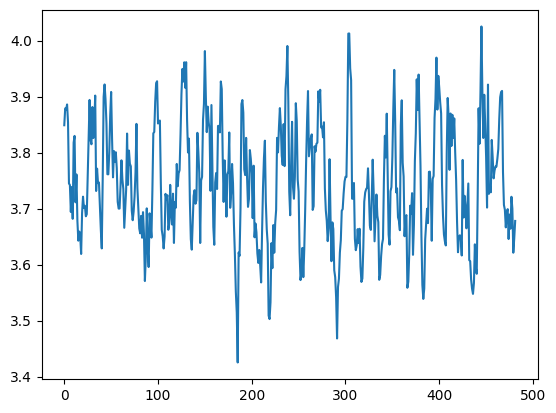

In [22]:
new_videos = torch.from_numpy(custom_stimuli).to(device) # shape: (1, 3, 500, 36, 64)
new_kwargs = {
    'data_key': data_key,
    'pupil_center': torch.zeros(new_videos.shape[0], 2, new_videos.shape[2]).to(device), # .cpu(), # .cuda(),
    # 'behavior': new_videos[:,1:,:,0,0],
}
predicted_responses = factorised_3d_model(new_videos.float(), **new_kwargs)
print (f'predicted_responses.shape: {predicted_responses.shape}') 
predicted_responses = predicted_responses.detach().cpu().numpy()
plt.plot(predicted_responses[0,:,2000])